# 13a_dataset_merge.ipynb

## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT764  
**Prepared by:** Subathira Thinakaran  
**Modified by:** Khalid Ameen (KA)

**Project Team:**  
- Suba (225094537)  
- Burhan (224802775)  
- Khalid (224696667)  

**Task:** Dataset Integration (Week 5 of 8)

## Objective
This notebook integrates the crash, weather, and mobility feature datasets into a single modelling-ready dataset for the TARP project.

The integration process focuses on:
- merging crash and weather data using date
- aligning temporal fields across datasets
- merging mobility features using common temporal keys
- creating a final dataset for modelling and dashboard use

## Output
- `final_model_dataset.csv`

In [5]:
# -----------------------------
# 1. Import libraries
# -----------------------------
from pathlib import Path
import pandas as pd

## Load Feature Datasets

This section loads the engineered crash, weather, and mobility datasets prepared by the team in the previous stage.

In [7]:
# -----------------------------
# 2. Load datasets
# -----------------------------
FEATURE_DATA_DIR = Path(r"D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\processed")

crash_file = FEATURE_DATA_DIR / "crash_features_engineered.csv"
weather_file = FEATURE_DATA_DIR / "cleaned_weather_data_with_features.csv"
mobility_file = FEATURE_DATA_DIR / "mobility_features.csv"

# Fallback for Colab/manual upload
if not crash_file.exists():
    print("Using uploaded files in current directory...")
    crash_file = Path("crash_features_engineered.csv")
    weather_file = Path("cleaned_weather_data_with_features.csv")
    mobility_file = Path("mobility_features.csv")

crash_df = pd.read_csv(crash_file)
weather_df = pd.read_csv(weather_file)
mobility_df = pd.read_csv(mobility_file)

print("Dataset summary:")
print(f"Crash dataset shape: {crash_df.shape}")
print(f"Weather dataset shape: {weather_df.shape}")
print(f"Mobility dataset shape: {mobility_df.shape}")

Dataset summary:
Crash dataset shape: (194352, 63)
Weather dataset shape: (4046, 46)
Mobility dataset shape: (168, 5)


### Observation

All three datasets were loaded successfully. The crash dataset is the largest and will act as the main event-level dataset, while the weather dataset provides environmental context and the mobility dataset provides temporal lookup features.

The difference in dataset sizes is expected and supports the planned integration approach.

## Initial Inspection

This step inspects the datasets to confirm key columns required for integration.

In [8]:
# -----------------------------
# 3. Initial inspection
# -----------------------------
print("Crash columns:")
print(list(crash_df.columns))

print("\nWeather columns:")
print(list(weather_df.columns))

print("\nMobility columns:")
print(list(mobility_df.columns))

print("\nCrash preview:")
display(crash_df.head())

print("\nWeather preview:")
display(weather_df.head())

print("\nMobility preview:")
display(mobility_df.head())

Crash columns:
['ACCIDENT_NO', 'ACCIDENT_DATE', 'ACCIDENT_TIME', 'ACCIDENT_TYPE', 'DAY_OF_WEEK', 'DCA_CODE', 'DCA_CODE_DESCRIPTION', 'LIGHT_CONDITION', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SEVERITY', 'SPEED_ZONE', 'RUN_OFFROAD', 'ROAD_NAME', 'ROAD_TYPE', 'ROAD_ROUTE_1', 'LGA_NAME', 'DTP_REGION', 'LATITUDE', 'LONGITUDE', 'VICGRID_X', 'VICGRID_Y', 'TOTAL_PERSONS', 'INJ_OR_FATAL', 'FATALITY', 'SERIOUSINJURY', 'OTHERINJURY', 'NONINJURED', 'MALES', 'FEMALES', 'BICYCLIST', 'PASSENGER', 'DRIVER', 'PEDESTRIAN', 'PILLION', 'MOTORCYCLIST', 'UNKNOWN', 'PED_CYCLIST_5_12', 'PED_CYCLIST_13_18', 'OLD_PED_65_AND_OVER', 'OLD_DRIVER_75_AND_OVER', 'YOUNG_DRIVER_18_25', 'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE', 'MOTORCYCLE', 'PT_VEHICLE', 'DEG_URBAN_NAME', 'SRNS', 'RMA', 'DIVIDED', 'STAT_DIV_NAME', 'hour', 'day_name', 'month', 'year', 'hour_of_day', 'day_of_week', 'weekend_flag', 'rush_hour', 'speed_zone_numeric', 'time_period', 'week_part']

Weather columns:
['Date', 'Min temperature (°C)', 'Ma

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,DAY_OF_WEEK,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,...,day_name,month,year,hour_of_day,day_of_week,weekend_flag,rush_hour,speed_zone_numeric,time_period,week_part
0,T20230013207,2023-06-06,1900-01-01 22:14:00,Collision with vehicle,Tuesday,140,U TURN,Dark Street lights on,Yes,Not at intersection,...,Tuesday,6,2023,22,Tuesday,0,0,50.0,Off-Peak,Weekday
1,T20240014902,2024-04-19,1900-01-01 02:10:00,Collision with vehicle,Friday,140,U TURN,Dark Street lights on,Yes,Not at intersection,...,Friday,4,2024,2,Friday,0,0,40.0,Off-Peak,Weekday
2,T20160009452,2016-04-30,1900-01-01 23:50:00,Collision with vehicle,Saturday,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,...,Saturday,4,2016,23,Saturday,1,0,100.0,Off-Peak,Weekend
3,T20230001223,2023-01-17,1900-01-01 15:56:00,Collision with vehicle,Tuesday,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,Private property,...,Tuesday,1,2023,15,Tuesday,0,1,100.0,Evening Peak,Weekday
4,T20220001324,2022-01-21,1900-01-01 22:45:00,Fall from or in moving vehicle,Friday,190,FELL IN/FROM VEHICLE,Dark Street lights on,Yes,Cross intersection,...,Friday,1,2022,22,Friday,0,0,50.0,Off-Peak,Weekday



Weather preview:


,Date,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),...,wind_dir_S/SSW,wind_dir_SE,wind_dir_SSE,wind_dir_SSW,wind_dir_SW,wind_dir_W,wind_dir_WNW,wind_dir_WSW,wind_dir_WSW / S,wind_dir_
0,2015-01-01,13.6,26.1,0.0,17:00,SSW,20.0,28.0,1015.9,92.0,...,0,0,0,1,0,0,0,0,0,0
1,2015-01-02,15.5,38.2,0.0,13:30,NNW,22.0,33.0,1015.5,92.0,...,0,0,0,0,0,0,0,0,0,0
2,2015-01-03,21.8,37.7,0.0,14:30,N,37.0,57.0,1012.6,84.0,...,0,0,0,0,0,0,0,0,0,0
3,2015-01-04,16.0,22.4,4.2,2:30,NNE,20.0,41.0,1020.4,93.0,...,0,0,0,0,0,0,0,0,0,0
4,2015-01-05,15.1,21.5,0.0,18:00,SSW,22.0,41.0,1021.0,86.0,...,0,0,0,1,0,0,0,0,0,0



Mobility preview:


,hour_of_day,day_of_week,weekend_flag,pedestrian_density,bicycle_density
0,0,Monday,0,0.046343,0.013089
1,1,Monday,0,0.012269,0.000000
2,2,Monday,0,0.008296,0.005236
3,3,Monday,0,0.000000,0.005236
4,4,Monday,0,0.005817,0.020942


### Observation

The crash, weather, and mobility datasets are available and contain the key fields needed for integration. The weather dataset is daily, while the mobility dataset is structured as a temporal lookup table using `hour_of_day`, `day_of_week`, and `weekend_flag`.

This means crash and weather will first be merged by date, after which mobility features will be added using shared temporal keys.

## Standardise Date Columns

This step standardises date column names and formats across the crash and weather datasets.

In [9]:
# -----------------------------
# 4. Standardise date columns
# -----------------------------
# Rename date columns for consistency
if "ACCIDENT_DATE" in crash_df.columns:
    crash_df = crash_df.rename(columns={"ACCIDENT_DATE": "date"})

if "Date" in weather_df.columns:
    weather_df = weather_df.rename(columns={"Date": "date"})

# Convert to datetime
crash_df["date"] = pd.to_datetime(crash_df["date"], errors="coerce")
weather_df["date"] = pd.to_datetime(weather_df["date"], errors="coerce")

print("Missing crash dates:", crash_df["date"].isna().sum())
print("Missing weather dates:", weather_df["date"].isna().sum())

print("\nCrash date range:", crash_df["date"].min(), "to", crash_df["date"].max())
print("Weather date range:", weather_df["date"].min(), "to", weather_df["date"].max())

Missing crash dates: 0
Missing weather dates: 0

Crash date range: 2012-01-01 00:00:00 to 2025-07-31 00:00:00
Weather date range: 2015-01-01 00:00:00 to 2026-02-28 00:00:00


### Observation

The date fields were successfully standardised across crash and weather datasets. This ensures that the first stage of integration can be performed consistently using a shared `date` column.

### Filter Crash Data to Match Weather Coverage

The weather dataset starts from 2015, while the crash dataset includes earlier years. To avoid missing weather values after merging, the crash dataset is filtered to the overlapping period only.

In [10]:
# -----------------------------
# 5. Filter crash data to match weather coverage
# -----------------------------
crash_df = crash_df[crash_df["date"] >= "2015-01-01"].copy()

print("Filtered crash dataset shape:", crash_df.shape)
print("Filtered crash date range:", crash_df["date"].min(), "to", crash_df["date"].max())

Filtered crash dataset shape: (151951, 63)
Filtered crash date range: 2015-01-01 00:00:00 to 2025-07-31 00:00:00


### Observation
Crash data was filtered to match weather data availability (from 2015 onwards), ensuring no missing weather values after merging.

In [11]:
# -----------------------------
# 6. Clean datasets
# -----------------------------

# Remove unnecessary duplicate day columns in crash
crash_df = crash_df.drop(columns=["DAY_OF_WEEK", "day_name"], errors="ignore")

# Remove corrupted weather column
weather_df = weather_df.drop(columns=["wind_dir_\x97"], errors="ignore")

### Observation
Redundant and inconsistent columns were removed to ensure a cleaner dataset structure before merging.

In [12]:
# -----------------------------
# 7. Remove duplicate weather dates
# -----------------------------
print("Duplicate dates:", weather_df["date"].duplicated().sum())

weather_df = weather_df.drop_duplicates(subset=["date"])

print("Weather shape after fix:", weather_df.shape)

Duplicate dates: 1
Weather shape after fix: (4045, 45)


### Observation
Duplicate dates in the weather dataset were removed to ensure a one-to-one merge with crash data.

In [39]:
# ------------------------------
# Inspect inconsistent wind-direction columns (KA)
# ------------------------------

wind_cols_check = [
    "wind_dir_N / NNW",
    "wind_dir_NNW",
    "wind_dir_NW/NNW",
    "wind_dir_NW",
    "wind_dir_S / SSW",
    "wind_dir_S/SSW",
    "wind_dir_WSW / S"
]

existing_wind_cols = [col for col in wind_cols_check if col in weather_df.columns]

print("Inconsistent wind-direction columns found:")
print(existing_wind_cols)

print("\nColumn sums:")
print(weather_df[existing_wind_cols].sum())

Inconsistent wind-direction columns found:
['wind_dir_NNW', 'wind_dir_NW']

Column sums:
wind_dir_NNW    279.0
wind_dir_NW     150.0
dtype: float64


In [38]:
# ------------------------------
# Clean inconsistent wind-direction columns (KA)
# ------------------------------

# Move tiny duplicate values into cleaner columns
if "wind_dir_N / NNW" in weather_df.columns and "wind_dir_NNW" in weather_df.columns:
    weather_df["wind_dir_NNW"] = weather_df["wind_dir_NNW"] + weather_df["wind_dir_N / NNW"]

if "wind_dir_NW/NNW" in weather_df.columns and "wind_dir_NW" in weather_df.columns:
    weather_df["wind_dir_NW"] = weather_df["wind_dir_NW"] + weather_df["wind_dir_NW/NNW"]

if "wind_dir_S / SSW" in weather_df.columns:
    if "wind_dir_SSW" in weather_df.columns:
        weather_df["wind_dir_SSW"] = weather_df["wind_dir_SSW"] + weather_df["wind_dir_S / SSW"]
    else:
        weather_df["wind_dir_SSW"] = weather_df["wind_dir_S / SSW"]

if "wind_dir_S/SSW" in weather_df.columns:
    if "wind_dir_SSW" in weather_df.columns:
        weather_df["wind_dir_SSW"] = weather_df["wind_dir_SSW"] + weather_df["wind_dir_S/SSW"]
    else:
        weather_df["wind_dir_SSW"] = weather_df["wind_dir_S/SSW"]

if "wind_dir_WSW / S" in weather_df.columns:
    if "wind_dir_WSW" in weather_df.columns:
        weather_df["wind_dir_WSW"] = weather_df["wind_dir_WSW"] + weather_df["wind_dir_WSW / S"]
    else:
        weather_df["wind_dir_WSW"] = weather_df["wind_dir_WSW / S"]

# Drop messy duplicate columns
cols_to_drop = [
    "wind_dir_N / NNW",
    "wind_dir_NW/NNW",
    "wind_dir_S / SSW",
    "wind_dir_S/SSW",
    "wind_dir_WSW / S"
]

existing_cols_to_drop = [col for col in cols_to_drop if col in weather_df.columns]
weather_df = weather_df.drop(columns=existing_cols_to_drop)

print("Dropped inconsistent wind-direction columns:")
print(existing_cols_to_drop)

Dropped inconsistent wind-direction columns:
[]


In [37]:
# ------------------------------
# Validate cleaned wind-direction columns (KA)
# ------------------------------

for col in weather_df.columns:
    if "wind_dir" in col:
        print(col)

wind_dir_Calm
wind_dir_E
wind_dir_ENE
wind_dir_ESE
wind_dir_N
wind_dir_NE
wind_dir_NNE
wind_dir_NNW
wind_dir_NW
wind_dir_S
wind_dir_SE
wind_dir_SSE
wind_dir_SSW
wind_dir_SW
wind_dir_W
wind_dir_WNW
wind_dir_WSW


### Merge Crash and Weather Data

This step merges the crash and weather datasets using the shared `date` field.

In [28]:
# ------------------------------
# Repair missing daily weather dates (KA)
# ------------------------------

# Sort weather data by date
weather_df = weather_df.sort_values("date").copy()

# Create full daily date range
full_weather_dates = pd.date_range(
    start=weather_df["date"].min(),
    end=weather_df["date"].max(),
    freq="D"
)

# Reindex weather data to include all dates
weather_df = (
    weather_df.set_index("date")
    .reindex(full_weather_dates)
    .rename_axis("date")
    .reset_index()
)

print("Weather dataset shape after adding missing dates:", weather_df.shape)
print("Missing dates added into weather dataset.")

Weather dataset shape after adding missing dates: (4077, 45)
Missing dates added into weather dataset.


In [40]:
# ------------------------------
# Fill missing weather values (KA)
# ------------------------------

# Numeric weather columns
numeric_weather_cols = weather_df.select_dtypes(include=["number"]).columns.tolist()

# Fill numeric columns using forward fill then backward fill
weather_df[numeric_weather_cols] = weather_df[numeric_weather_cols].ffill().bfill()

# Fill non-numeric columns if needed
non_numeric_weather_cols = weather_df.select_dtypes(exclude=["number"]).columns.tolist()
non_numeric_weather_cols = [col for col in non_numeric_weather_cols if col != "date"]

for col in non_numeric_weather_cols:
    weather_df[col] = weather_df[col].ffill().bfill()

print("Missing values after filling weather data:")
print(weather_df.isnull().sum().sort_values(ascending=False).head(20))

Missing values after filling weather data:
date                    0
Min temperature (°C)    0
is_heavy_rain_day       0
wind_dir_Calm           0
wind_dir_E              0
wind_dir_ENE            0
wind_dir_ESE            0
wind_dir_N              0
wind_dir_NE             0
wind_dir_NNE            0
wind_dir_NNW            0
wind_dir_NW             0
wind_dir_S              0
wind_dir_SE             0
wind_dir_SSE            0
wind_dir_SSW            0
wind_dir_SW             0
wind_dir_W              0
wind_dir_WNW            0
is_hot_day              0
dtype: int64


In [41]:
# -----------------------------
# 8. Merge crash and weather datasets (KA)
# -----------------------------
crash_weather_df = pd.merge(
    crash_df,
    weather_df,
    on="date",
    how="left"
)

print("Crash dataset shape:", crash_df.shape)
print("Weather dataset shape:", weather_df.shape)
print("Crash + weather merged shape:", crash_weather_df.shape)

Crash dataset shape: (151951, 61)
Weather dataset shape: (4077, 40)
Crash + weather merged shape: (151951, 100)


In [42]:
# ------------------------------
# 8a. Validate weather merge (KA)
# ------------------------------

weather_cols_to_check = [
    "Total Rainfall (mm)",
    "Max temperature (°C)",
    "max wind speed (km/h)"
]

print("Missing values in key weather columns after merge:")
print(crash_weather_df[weather_cols_to_check].isnull().sum())

print("\nPercentage missing in key weather columns:")
print((crash_weather_df[weather_cols_to_check].isnull().mean() * 100).round(2))

Missing values in key weather columns after merge:
Total Rainfall (mm)      0
Max temperature (°C)     0
max wind speed (km/h)    0
dtype: int64

Percentage missing in key weather columns:
Total Rainfall (mm)      0.0
Max temperature (°C)     0.0
max wind speed (km/h)    0.0
dtype: float64


### [Updated] Observation

A small number of daily weather records were missing from the original weather dataset. These dates were restored using a complete daily date index, and missing weather values were filled using neighbouring daily observations. This ensured full alignment between crash dates and daily weather conditions before merging.

## Merge Mobility Features

This step adds the pedestrian and bicycle density features using the shared temporal keys:
- `hour_of_day`
- `day_of_week`
- `weekend_flag`

In [14]:
# -----------------------------
# 9. Merge mobility features
# -----------------------------
final_model_df = pd.merge(
    crash_weather_df,
    mobility_df,
    on=["hour_of_day", "day_of_week", "weekend_flag"],
    how="left"
)

print("Crash + weather dataset shape:", crash_weather_df.shape)
print("Mobility dataset shape:", mobility_df.shape)
print("Final merged dataset shape:", final_model_df.shape)

final_model_df.head()

Crash + weather dataset shape: (151951, 105)
Mobility dataset shape: (168, 5)
Final merged dataset shape: (151951, 107)


,ACCIDENT_NO,date,ACCIDENT_TIME,ACCIDENT_TYPE,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,SEVERITY,...,wind_dir_SE,wind_dir_SSE,wind_dir_SSW,wind_dir_SW,wind_dir_W,wind_dir_WNW,wind_dir_WSW,wind_dir_WSW / S,pedestrian_density,bicycle_density
0,T20230013207,2023-06-06,1900-01-01 22:14:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.115603,0.026178
1,T20240014902,2024-04-19,1900-01-01 02:10:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Other injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011888,0.000000
2,T20160009452,2016-04-30,1900-01-01 23:50:00,Collision with vehicle,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.269190,0.005236
3,T20230001223,2023-01-17,1900-01-01 15:56:00,Collision with vehicle,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,Private property,Serious injury accident,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.615111,0.089005
4,T20220001324,2022-01-21,1900-01-01 22:45:00,Fall from or in moving vehicle,190,FELL IN/FROM VEHICLE,Dark Street lights on,Yes,Cross intersection,Serious injury accident,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.303805,0.123037


### Observation
Mobility features were successfully added using temporal keys, enriching the dataset with behavioural patterns.

In [15]:
# -----------------------------
# 10. Validation
# -----------------------------
print("Missing pedestrian_density:", final_model_df["pedestrian_density"].isna().sum())
print("Missing bicycle_density:", final_model_df["bicycle_density"].isna().sum())

print("\nDuplicate rows:", final_model_df.duplicated().sum())

Missing pedestrian_density: 0
Missing bicycle_density: 0

Duplicate rows: 0


### Observation

The final dataset was successfully created by merging crash, weather, and mobility datasets.

The row count remained consistent throughout the integration process, confirming that no unintended duplication or data loss occurred.

Mobility features (`pedestrian_density`, `bicycle_density`) were successfully mapped using temporal keys, ensuring that each crash record is enriched with contextual behavioural patterns.

The dataset is now ready for validation, visualisation, and predictive modelling.

In [43]:
# ------------------------------
# 10a. Check for possible feature leakage (KA)
# ------------------------------

leakage_keywords = [
    "inj", "fatal", "serious", "other", "persons", "severity"
]

possible_leakage_cols = [
    col for col in final_model_df.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

print("Possible leakage columns:")
for col in possible_leakage_cols:
    print(col)

Possible leakage columns:
SEVERITY
TOTAL_PERSONS
INJ_OR_FATAL
FATALITY
SERIOUSINJURY
OTHERINJURY
NONINJURED


In [44]:
# ------------------------------
# 10b. Review crash-related columns (KA)
# ------------------------------

for col in final_model_df.columns:
    if any(word in col.lower() for word in ["inj", "fatal", "serious", "other", "person", "severity", "crash", "accident"]):
        print(col)

ACCIDENT_NO
ACCIDENT_TIME
ACCIDENT_TYPE
SEVERITY
TOTAL_PERSONS
INJ_OR_FATAL
FATALITY
SERIOUSINJURY
OTHERINJURY
NONINJURED


In [49]:
# ------------------------------
# 10c. Prepare final modelling data using SEVERITY (KA)
# ------------------------------

target_col = "SEVERITY"

leakage_cols_to_drop = [
    "SEVERITY",       # target, so remove from X
    "INJ_OR_FATAL",
    "FATALITY",
    "SERIOUSINJURY",
    "OTHERINJURY",
    "NONINJURED",
    "TOTAL_PERSONS"
]

X = final_model_df.drop(columns=leakage_cols_to_drop, errors="ignore").copy()
y = final_model_df[target_col].copy()

print("Predictor dataset (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nSeverity distribution:")
print(y.value_counts())

print("\nSeverity proportions:")
print((y.value_counts(normalize=True) * 100).round(2))

Predictor dataset (X) shape: (151951, 100)
Target (y) shape: (151951,)

Severity distribution:
SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Non injury accident            4
Name: count, dtype: int64

Severity proportions:
SEVERITY
Other injury accident      61.95
Serious injury accident    36.38
Fatal accident              1.67
Non injury accident         0.00
Name: proportion, dtype: float64


**Important Notes**

Added a feature leakage check to the merged dataset before modelling. This showed that several columns were too closely tied to the crash outcome, including INJ_OR_FATAL, FATALITY, SERIOUSINJURY, OTHERINJURY, NONINJURED, SEVERITY, and TOTAL_PERSONS. Since our final target variable is SEVERITY, I separated it from the predictor set and excluded the other outcome-related columns from the model inputs. This makes the modelling setup cleaner and helps avoid inflated results caused by leakage.

In [50]:
# ------------------------------
# 10d. Check target class balance for SEVERITY (KA)
# ------------------------------

print("Target counts:")
print(y.value_counts())

print("\nTarget proportions:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nMissing values in target:")
print(y.isnull().sum())

Target counts:
SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Non injury accident            4
Name: count, dtype: int64

Target proportions:
SEVERITY
Other injury accident      61.95
Serious injury accident    36.38
Fatal accident              1.67
Non injury accident         0.00
Name: proportion, dtype: float64

Missing values in target:
0


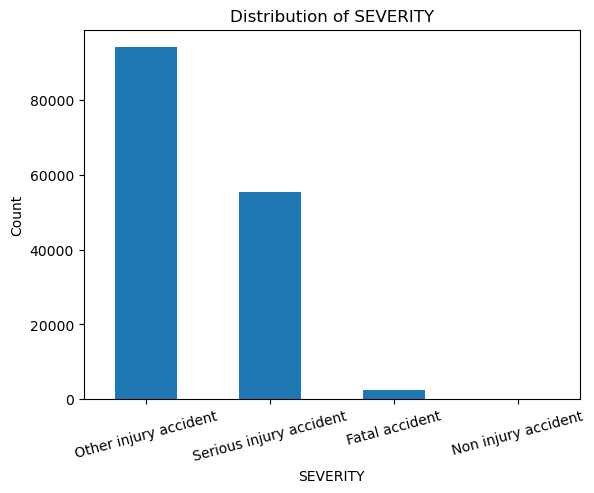

In [51]:
# ------------------------------
# 10e. Visualise SEVERITY class balance (KA)
# ------------------------------

import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Distribution of SEVERITY")
plt.xlabel("SEVERITY")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

In [52]:
# ------------------------------
# 10f. Remove extremely rare target class (KA)
# ------------------------------

rare_class = "Non injury accident"

mask = y != rare_class
X = X[mask].copy()
y = y[mask].copy()

print("Updated predictor dataset (X) shape:", X.shape)
print("Updated target (y) shape:", y.shape)

print("\nUpdated SEVERITY distribution:")
print(y.value_counts())

print("\nUpdated SEVERITY proportions:")
print((y.value_counts(normalize=True) * 100).round(2))

Updated predictor dataset (X) shape: (151947, 100)
Updated target (y) shape: (151947,)

Updated SEVERITY distribution:
SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Name: count, dtype: int64

Updated SEVERITY proportions:
SEVERITY
Other injury accident      61.95
Serious injury accident    36.38
Fatal accident              1.67
Name: proportion, dtype: float64


### Observation (KA)

The final modelling target was set to SEVERITY. Because the Non injury accident class contained only 4 records, it was removed to make the later classification task more stable. The resulting dataset is now ready for the modelling stage, where train-test splitting, encoding, and model training will be completed.

## Save Final Dataset

This section saves the integrated dataset for the next project stages:
- validation
- feature visualisation
- predictive modelling
- dashboard integration

In [54]:
# -----------------------------
# 11. Save final dataset
# -----------------------------
from pathlib import Path

OUTPUT_DIR = Path(r"D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\final")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

final_model_dataset_file = OUTPUT_DIR / "updated_final_model_dataset.csv"

final_model_df.to_csv(final_model_dataset_file, index=False)

print("Saved updated_final_model_dataset.csv")

Saved updated_final_model_dataset.csv


In [55]:
# -----------------------------
# 13. Download feature files (optional)
# -----------------------------
print("File saved at:")
print(final_model_dataset_file.resolve())

File saved at:
D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\final\updated_final_model_dataset.csv


## Output

The dataset integration process generated:

- `updated_final_model_dataset.csv`

This final dataset combines:
- crash features
- weather features
- mobility features (`pedestrian_density`, `bicycle_density`)

It provides the modelling-ready input required for the next stage of the TARP project and supports the future dashboard vision by consolidating the project’s key predictors into one dataset.

## Final Summary

This notebook successfully integrated the crash, weather, and mobility datasets into a single modelling-ready dataset for the TARP project.

The crash and weather datasets were first merged using the `date` field, after which mobility features were added using shared temporal keys: `hour_of_day`, `day_of_week`, and `weekend_flag`.

The resulting `updated_final_model_dataset.csv` provides a unified representation of accident events, environmental conditions, and mobility intensity. This integrated dataset forms the foundation for the next stages of the project, including validation, visualisation, modelling, and dashboard development.